In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def make_problem_data(
    n_steps,
    target_weights,          # teacher weight on each feature's CLEAN signal (scalar or list)
    *,
    feature_noise=0.0,       # noise coefficient c per feature (scalar or list)
    target_noise_std=0.1,    # std of additive Gaussian noise on the target
    shared_signal=False,     # if True, all features are noisy views of ONE signal
    seed=0,
):
    """Generate (features, target) for the feature-sifting linear-regression probe.

    The target is a fixed "teacher network": ``y = sum_j target_weights[j] * s_j
    + noise``, built from the CLEAN signals ``s_j``. The learner instead sees the
    noisy features ``f_j = (1 - c_j) * s_j + c_j * U(-1, 1)``. The teacher weights
    are held fixed regardless of the feature noise; the learner's *optimal* weight
    on a noisy feature is attenuated away from the teacher weight (regression
    dilution -- see ``optimal_weight``), so the dashed reference in the plots is
    the computed optimum, not the teacher weight.

    Every knob that may vary across experiments is a parameter:

    - ``target_weights``: teacher weight per feature on its clean signal -> sets
      the number of features. With clean features (``c = 0``) this is also the
      learner's optimal weight.
    - ``feature_noise``: per-feature noise coefficient ``c`` in
      ``f = (1 - c) * s + c * U(-1, 1)``;  ``c = 0`` gives a clean feature.
    - ``target_noise_std``: std of the Gaussian noise added to the target.
    - ``shared_signal``: if True every feature is a noisy view of the *same*
      underlying signal (the colinear / "blocking" case); otherwise each feature
      has its own independent signal.

    Returns ``features`` (n_steps, n_feat) and ``y`` (n_steps,).
    """
    rng = np.random.default_rng(seed)
    target_weights = np.atleast_1d(np.asarray(target_weights, dtype=float))
    n_feat = len(target_weights)
    c = np.broadcast_to(np.asarray(feature_noise, dtype=float), (n_feat,))

    # underlying clean signals
    if shared_signal:
        s = rng.uniform(-1.0, 1.0, size=n_steps)
        signals = [s] * n_feat
    else:
        signals = [rng.uniform(-1.0, 1.0, size=n_steps) for _ in range(n_feat)]

    features = np.empty((n_steps, n_feat))
    y = rng.normal(0.0, target_noise_std, size=n_steps)
    for j in range(n_feat):
        feat_noise = rng.uniform(-1.0, 1.0, size=n_steps)
        features[:, j] = (1 - c[j]) * signals[j] + c[j] * feat_noise
        y = y + target_weights[j] * signals[j]   # teacher weight on the clean signal

    return features, y


def optimal_weight(target_weight, feature_noise):
    """Least-squares optimal weight on a single *independent* noisy feature.

    With ``f = (1 - c) * s + c * u`` (Var(s) == Var(u)) and target component
    ``target_weight * s``, the optimum is
        ``w* = Cov(f, y) / Var(f) = target_weight * (1 - c) / ((1 - c)**2 + c**2)``.
    The learner shrinks the weight (regression attenuation) as the feature gets
    noisier:  ``w* -> target_weight`` at ``c = 0`` and ``w* -> 0`` as ``c -> 1``.
    Assumes the feature's signal is independent of the other features' signals.
    """
    c = np.asarray(feature_noise, dtype=float)
    return target_weight * (1 - c) / ((1 - c) ** 2 + c ** 2)


In [3]:
# ---------------------------------------------------------------------------
# First experiment: a single feature with clean inputs (no feature noise) and a
# noisy target, learned from a zero weight with constant-step-size LMS, while we
# *observe* candidate "maturity" indicators for its weight.
#
# Learning is plain LMS; the IDBD / IDBD3 h-traces are computed alongside with
# the same constant step-size, exactly as the project optimisers do:
#   IDBD : h <- h * max(1 - step_size*f**2, 0) + step_size * loss_grad
#   IDBD3: h <- h * max(1 - step_size*f**2, 0) +             loss_grad
# with loss_grad = 2*error*f. They never feed back into the weights.
# (With a constant step-size the two share the same decay term and differ only by
#  the factor step_size, so h_idbd == step_size * h_idbd3 exactly -- they coincide
#  once normalized.)
# ---------------------------------------------------------------------------

STEP_SIZE = 0.01
N_STEPS = 10_000
IDEAL_WEIGHTS = [0.0, 0.001, 0.01, 0.1, 0.5, 1.0]
TRACE_DECAYS = [0.9, 0.99, 0.999]


def run_lms_with_indicators(features, y, step_size=STEP_SIZE, trace_decays=TRACE_DECAYS,
                            w_init=None):
    """LMS over `features` (n_steps, n_feat); indicators are tracked for the
    feature under study, taken to be the LAST column. `step_size` is the constant
    LMS / IDBD step-size and the number of steps is set by len(features), so both
    are configurable per run. `w_init` defaults to zeros (a fresh weight); pass a
    vector to start e.g. an established weight at its optimum in the later blocking
    experiments."""
    n_steps, n_feat = features.shape
    tracked = n_feat - 1
    decays = np.asarray(trace_decays, dtype=float)
    n_dec = len(decays)

    w = np.zeros(n_feat) if w_init is None else np.asarray(w_init, dtype=float)
    h_idbd = 0.0
    h_idbd3 = 0.0
    dw_tr = np.zeros(n_dec)

    w_hist = np.empty((n_steps, n_feat))
    dw_trace_hist = np.empty((n_steps, n_dec))
    h_idbd_hist = np.empty(n_steps)
    h_idbd3_hist = np.empty(n_steps)

    for t in range(n_steps):
        f = features[t]
        error = float(w @ f) - y[t]              # y_hat - y  (project convention)

        fi = f[tracked]
        loss_grad = 2.0 * error * fi             # d(error**2)/dw_tracked
        decay_term = fi * fi                     # prediction-grad squared

        # IDBD / IDBD3 h-traces (observed only, constant step-size)
        keep = max(0.0, 1.0 - step_size * decay_term)
        h_idbd = h_idbd * keep + step_size * loss_grad
        h_idbd3 = h_idbd3 * keep + loss_grad

        # LMS weight update (constant step-size) for every weight
        dw = -step_size * (2.0 * error * f)
        w = w + dw

        # EMA traces of the tracked weight's changes
        dw_tr = decays * dw_tr + (1.0 - decays) * dw[tracked]

        w_hist[t] = w
        dw_trace_hist[t] = dw_tr
        h_idbd_hist[t] = h_idbd
        h_idbd3_hist[t] = h_idbd3

    return {'w': w_hist, 'dw_trace': dw_trace_hist,
            'h_idbd': h_idbd_hist, 'h_idbd3': h_idbd3_hist}


results = {}
for w_ideal in IDEAL_WEIGHTS:
    # single clean feature (no feature noise), target noise = 0.1
    feats, targ = make_problem_data(N_STEPS, [w_ideal], feature_noise=0.0,
                                    target_noise_std=0.1, seed=0)
    results[w_ideal] = run_lms_with_indicators(feats, targ, step_size=STEP_SIZE)


In [4]:
def _norm_peak(a):
    m = np.max(np.abs(a))
    return a / m if m > 0 else a

W_COLOR = 'black'
DW_COLORS = ['#3953e2', '#9923DC', '#029999']  # Brighter indigo, purple, dark aqua
H_IDBD3_COLOR = '#FF3300'  # slightly redder blood orange (stand-out)

### Reading the plots

One panel per ideal weight $w^*$ (including $w^* = 0$ — a useless feature whose weight
should stay at zero). A single feature with clean inputs is learned from a zero weight;
all the noise lives in the target ($\sigma = 0.1$).

**Left axis (true scale, black):** the weight (solid) and its ideal value (dashed). The
grey vertical line marks where the weight first reaches 90% of its ideal — a rough
"matured" reference (omitted for $w^* = 0$).

**Right axis (linear, coloured):** the candidate maturity indicators, each normalized to
unit peak so they are comparable (raw magnitudes differ by orders of magnitude). All are
shown in the weight-change sign convention ($-h$), so each indicator is positive while
the weight grows and collapses toward (and flips around) zero once the weight matures.

The IDBD / IDBD3 $h$-traces use the project's exact recursion
$h_t = h_{t-1}\,\max(1 - \alpha f^2,\,0) + (\alpha\ \text{or}\ 1)\cdot\text{loss\_grad}$,
with $\alpha$ held constant. They share the *same* decay multiplier and their additive
terms differ only by the constant factor $\alpha$, so $h^{\text{IDBD}}_t = \alpha\,
h^{\text{IDBD3}}_t$ for all $t$ — i.e. they are exactly proportional and coincide after
normalization. They only diverge once $\alpha$ is allowed to adapt (then the decay
multipliers differ too), which is a later experiment.


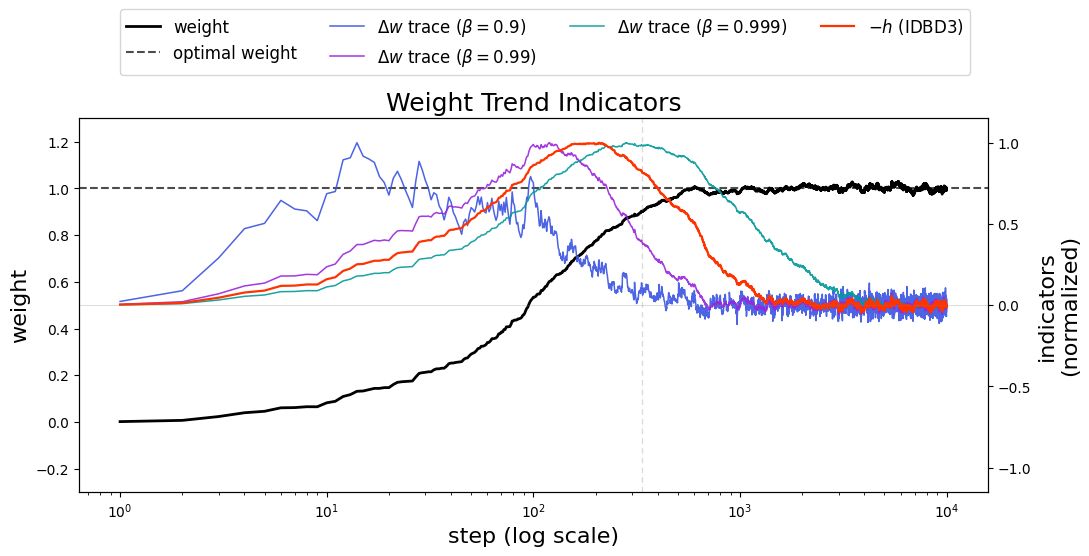

In [5]:

# Only plot the first optimal weight (single plot)
plot_steps = np.arange(1, N_STEPS + 1)

w_ideal = IDEAL_WEIGHTS[-1]
res = results[w_ideal]
w_opt = optimal_weight(w_ideal, 0.0)   # clean features -> equals the teacher weight

fig, ax = plt.subplots(figsize=(11, 5))
# --- left axis: the weight (true scale, black) ---
ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7, label='optimal weight')
ax.set_xscale('log')
ax.set_ylabel('weight', fontsize=16)
ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
ax.set_title(f'Weight Trend Indicators', fontsize=18)

# rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
if w_opt > 0:
    hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
    if len(hit):
        ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3)

# --- right axis: normalized maturity indicators (one colour each) ---
ax2 = ax.twinx()
for k, d in enumerate(TRACE_DECAYS):
    ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
             color=DW_COLORS[k], lw=1.1, alpha=0.9, label=f'$\Delta w$ trace ($\\beta = {d}$)')
ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
         label='$-h$ (IDBD3)')
ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
ax2.set_ylim(-1.15, 1.15)
ax2.set_ylabel('indicators\n(normalized)', fontsize=16)

ax.set_xlabel('step (log scale)', fontsize=16)

# Build legend with left and right handles/labels
hL, lL = ax.get_legend_handles_labels()
hR, lR = ax2.get_legend_handles_labels()
# Place the legend just above the axes, closer to the plot to reduce empty space
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.12),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))  # adjust so legend fits closely above plot
plt.show()


/tmp/ipykernel_6087/828059091.py:15: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)


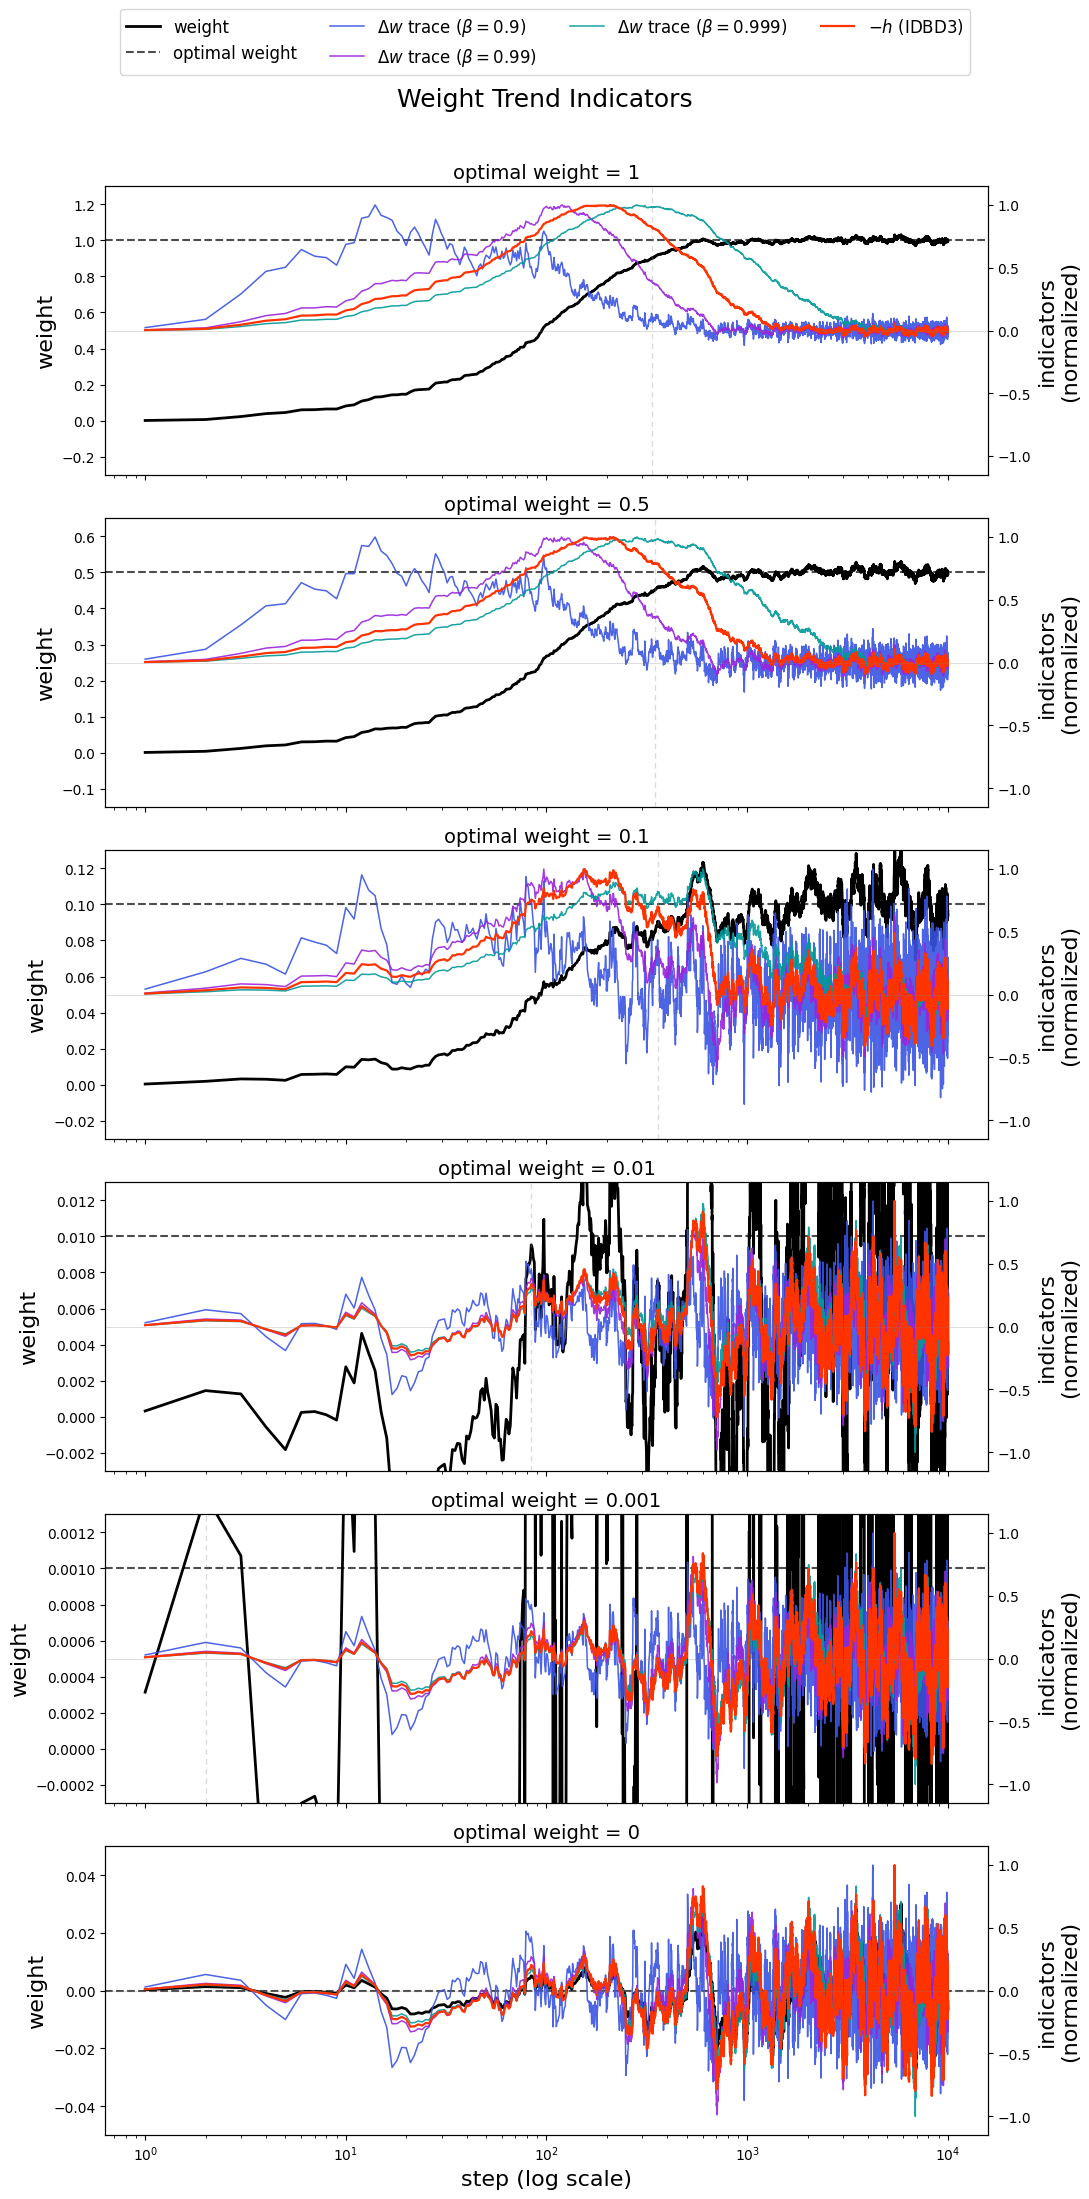

In [6]:
plot_steps = np.arange(1, N_STEPS + 1)
fig, axes = plt.subplots(len(IDEAL_WEIGHTS), 1,
                         figsize=(11, 3.6 * len(IDEAL_WEIGHTS)), sharex=True)
ax2_first = None
for ax, w_ideal in zip(axes, IDEAL_WEIGHTS[::-1]):
    res = results[w_ideal]
    w_opt = optimal_weight(w_ideal, 0.0)   # clean features -> equals the teacher weight

    # --- left axis: the weight (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight')
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'optimal weight = {w_opt:.3g}', fontsize=14)

    # rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3)

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.02),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Second experiment: sweep the step-size (optimal weight fixed at $w^* = 0.001$)

Exactly the first experiment's single clean-feature / noisy-target setup, but the
optimal weight is now held fixed at $w^* = 0.001$ and the constant LMS / IDBD
step-size is swept instead. One panel per step-size; the indicators, axes,
normalization, and (fixed) weight y-range are unchanged from the first experiment.


In [7]:
# ---------------------------------------------------------------------------
# Second experiment: identical single clean-feature / noisy-target setup as the
# first experiment, but now the optimal weight is held FIXED at 0.001 and the
# constant LMS / IDBD step-size is what we sweep (instead of sweeping the ideal
# weight). Clean feature -> optimal weight == teacher weight, so target_weights
# = [0.001] gives an optimal weight of 0.001 exactly. Everything else (the run
# function, indicators, noise, n_steps) is unchanged from the first experiment.
# ---------------------------------------------------------------------------

OPT_WEIGHT_SS = 0.01
STEP_SIZES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
n_steps = 1_000_000

results_ss = {}
for ss in STEP_SIZES:
    # single clean feature (no feature noise), target noise = 0.1
    feats, targ = make_problem_data(n_steps, [OPT_WEIGHT_SS], feature_noise=0.0,
                                    target_noise_std=0.1, seed=0)
    results_ss[ss] = run_lms_with_indicators(feats, targ, step_size=ss)


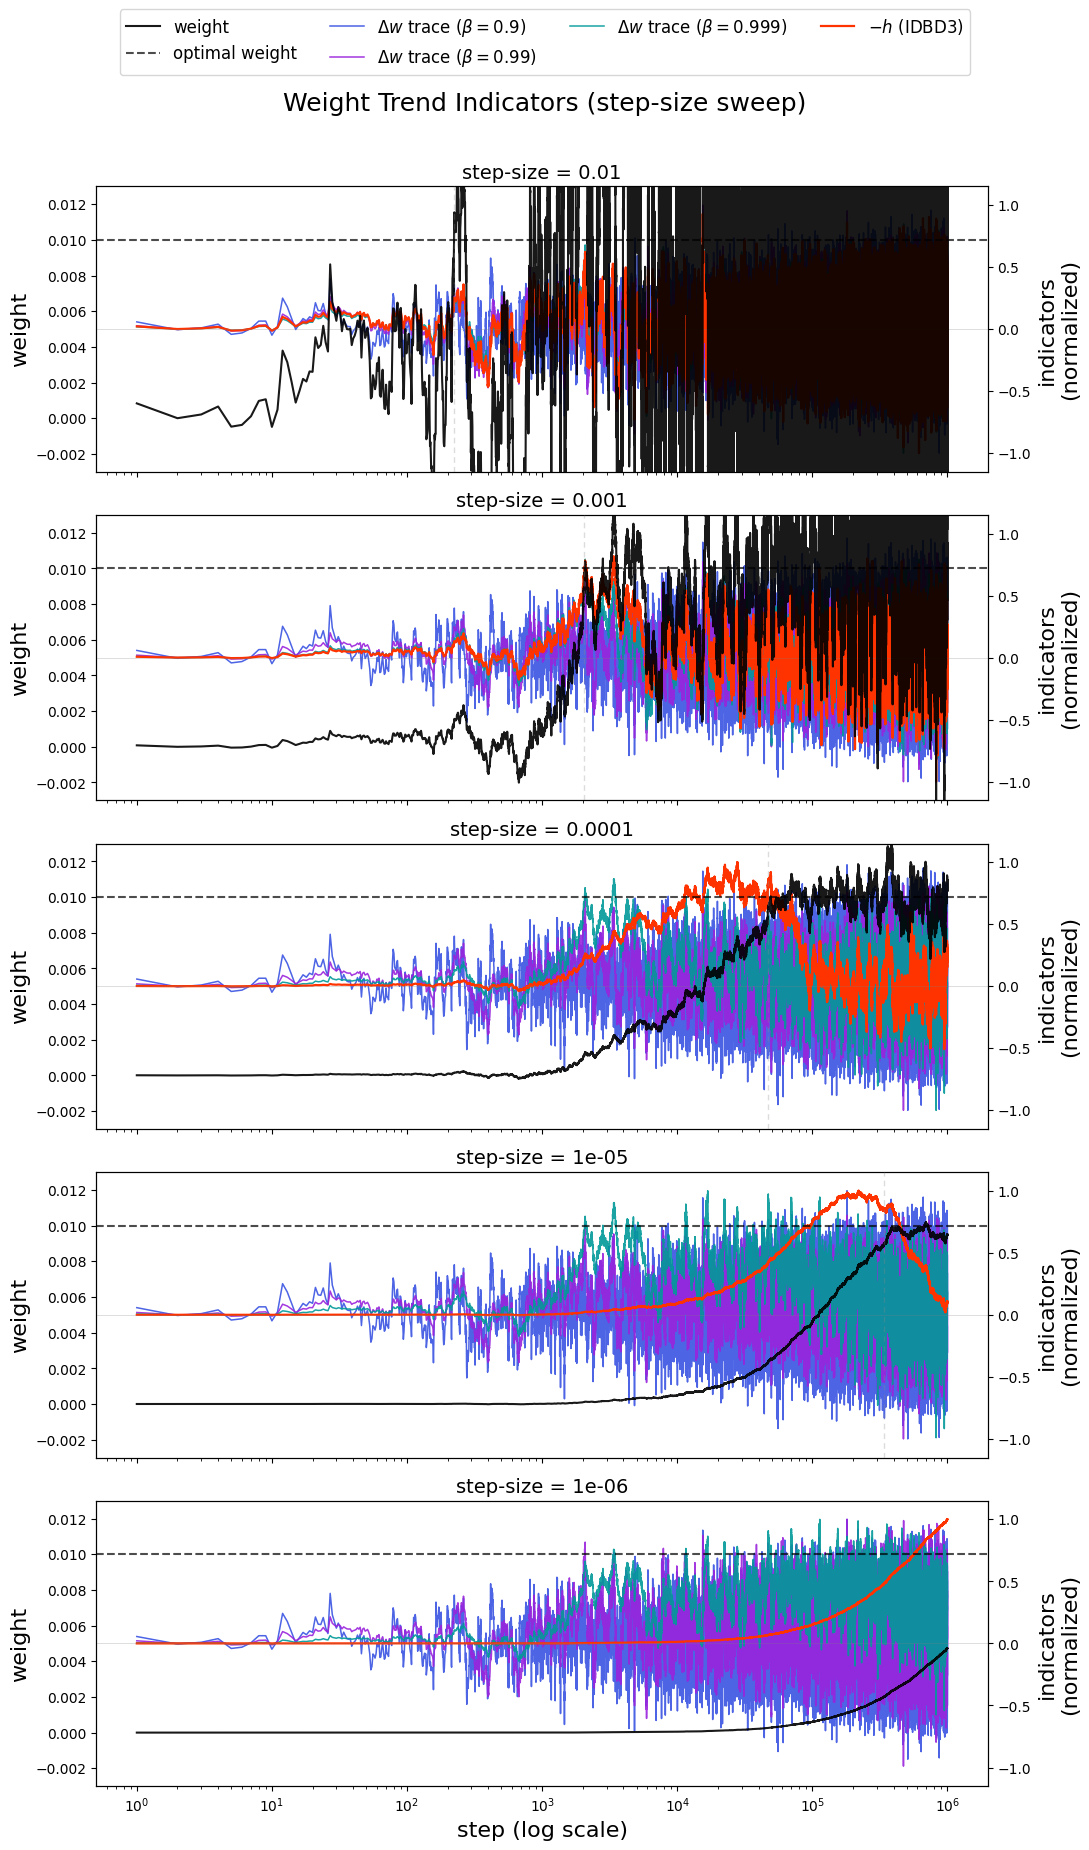

In [8]:
plot_steps = np.arange(1, n_steps + 1)
w_opt = optimal_weight(OPT_WEIGHT_SS, 0.0)   # clean feature -> equals 0.001
fig, axes = plt.subplots(len(STEP_SIZES), 1,
                         figsize=(11, 3.6 * len(STEP_SIZES)), sharex=True)
ax2_first = None
for ax, ss in zip(axes, STEP_SIZES[::-1]):
    res = results_ss[ss]

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weight (true scale, black), now plotted after the right axis lines ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=1.5, label='weight', zorder=10, alpha=0.9)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'step-size = {ss:.3g}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through


    # rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators (step-size sweep)', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Third experiment: blocking by an established feature

Now there are **two colinear features** — two noisy views of the *same* signal
(`shared_signal=True`), differing only in their noise:

- **Established feature** — pre-trained: its weight starts at the value that is
  optimal when it is the *only* feature present, $w^*_{\text{est}} =
  \text{optimal\_weight}(w^*, c_{\text{est}})$. Its noise $c_{\text{est}}$ is the
  swept variable (one panel each: $1.0, 0.5, 0.1, 0.01, 0.0$).
- **Incumbent feature** — the tracked feature from the earlier experiments: clean
  ($c = 0$), learned from a zero weight. It now has to compete with the
  established feature for the shared signal.

Because the established feature already explains part of the target, we expect it
to **partially block** the incumbent — the cleaner (lower-noise) the established
feature, the more it blocks, so the incumbent's weight settles further below its
solo optimum $w^*$ (the dashed reference).

Same plot as before, tracked on the **incumbent** feature, with one addition: a
**partially transparent** line for the established feature's weight.


In [9]:
# ---------------------------------------------------------------------------
# Third experiment: a *blocking* setup. Two colinear features (shared_signal),
# i.e. two noisy views of the SAME underlying signal, differing only in noise:
#   - established feature (column 0): pre-trained, weight initialised at the
#     value that is optimal when it is the ONLY feature present,
#     optimal_weight(W_TEACHER, c_est). Its noise c_est is what we sweep.
#   - incumbent feature  (column 1, the tracked one): clean (noise 0), learned
#     from a zero weight -- exactly the feature studied before, but now it has to
#     compete with the established feature for the shared signal.
# Shared signal -> the teacher target is W_TEACHER * s + noise regardless of how
# the teacher weight is split across columns, so we put it all on column 0
# ([W_TEACHER, 0.0]); the incumbent's solo optimum is still
# optimal_weight(W_TEACHER, 0) == W_TEACHER (the dashed reference). How far the
# established feature blocks the incumbent below that reference is the thing to
# watch. Run function, step-size, indicators and noise are as in the first
# experiment; the step count gets its own value below.
# ---------------------------------------------------------------------------

W_TEACHER = 0.5                              # teacher weight on the shared signal
INCUMBENT_NOISE = 0.0                        # incumbent (learns from scratch) is clean
EST_NOISES = [1.0, 0.5, 0.1, 0.01, 0.0]      # swept: noise of the established feature
N_STEPS_BLOCK = 500_000                      # training steps for this experiment

results_block = {}
for c_est in EST_NOISES:
    # column 0 = established feature (noise c_est), column 1 = incumbent (clean, tracked)
    feats, targ = make_problem_data(
        N_STEPS_BLOCK, [W_TEACHER, 0.0], feature_noise=[c_est, INCUMBENT_NOISE],
        target_noise_std=0.1, shared_signal=True, seed=0,
    )
    w_est0 = optimal_weight(W_TEACHER, c_est)   # established weight starts at its solo optimum
    results_block[c_est] = run_lms_with_indicators(
        feats, targ, step_size=STEP_SIZE, w_init=[w_est0, 0.0])


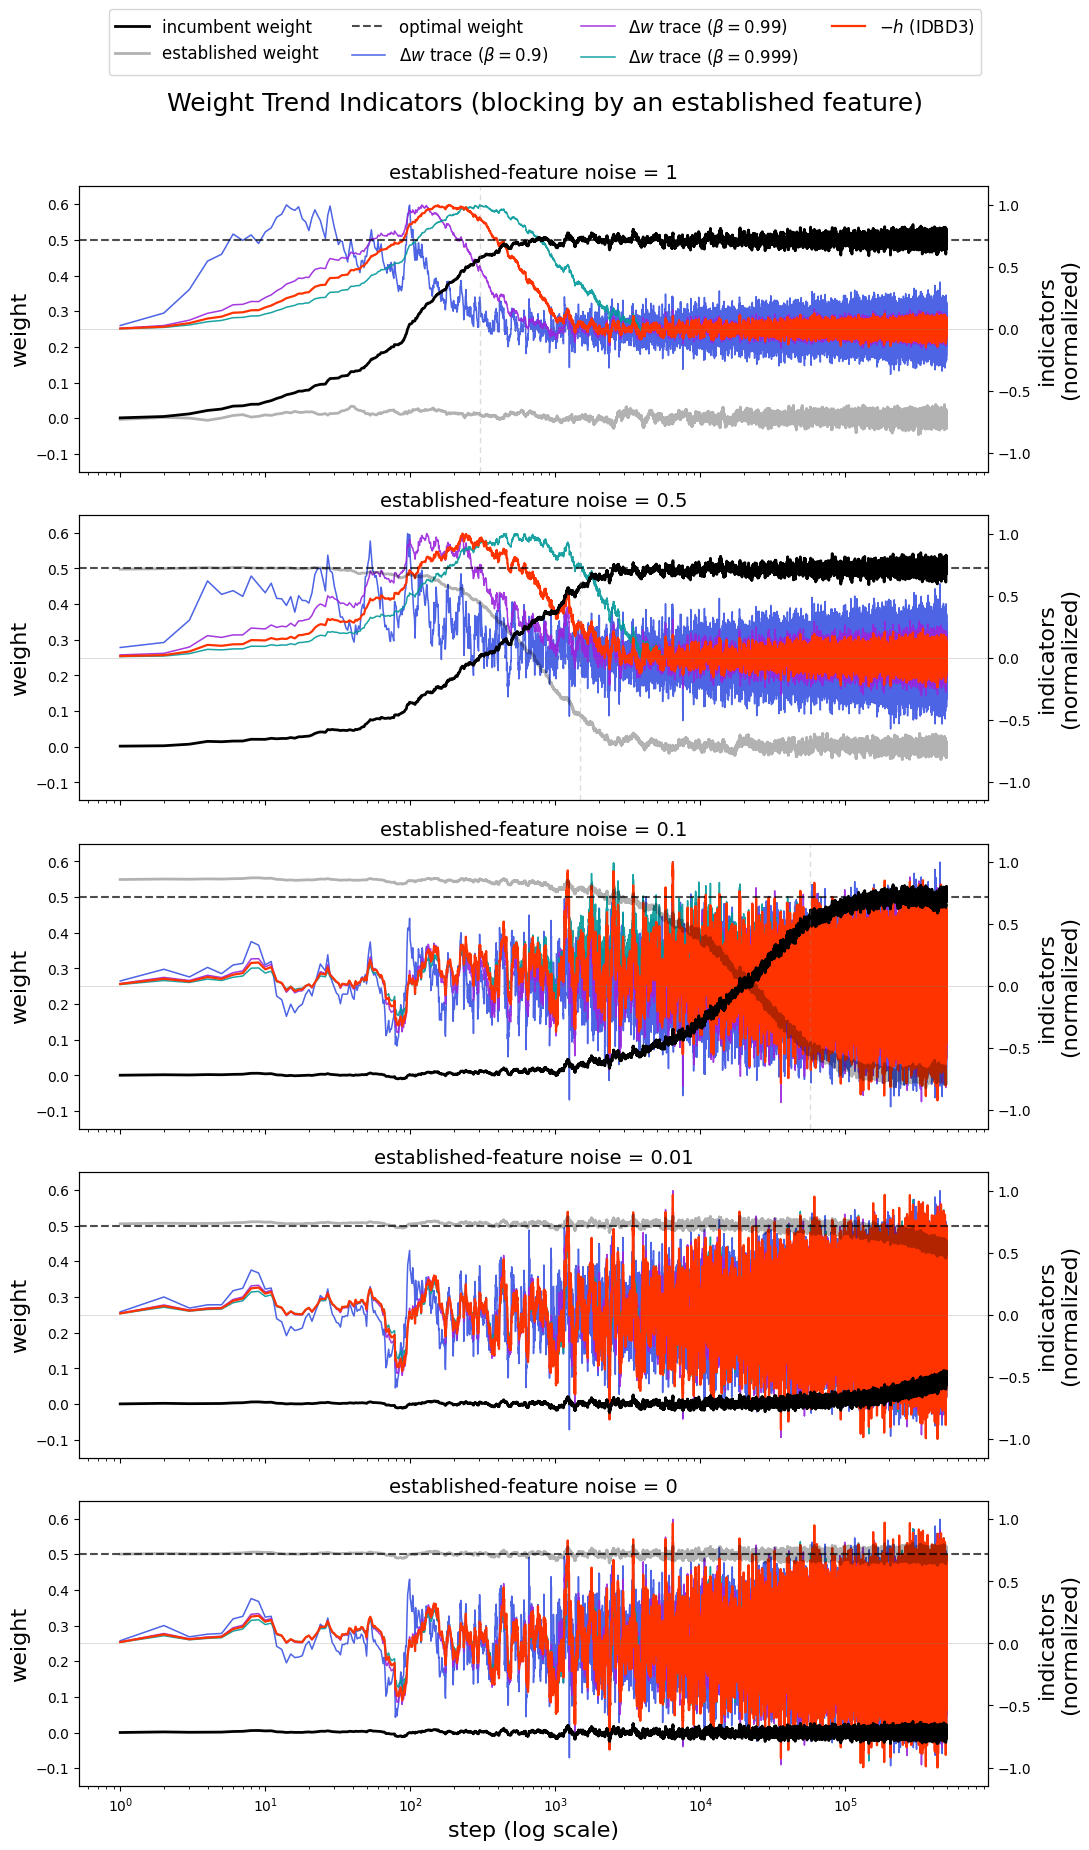

In [10]:
plot_steps = np.arange(1, N_STEPS_BLOCK + 1)
w_opt = optimal_weight(W_TEACHER, INCUMBENT_NOISE)   # clean incumbent -> equals W_TEACHER
fig, axes = plt.subplots(len(EST_NOISES), 1,
                         figsize=(11, 3.6 * len(EST_NOISES)), sharex=True)
ax2_first = None
for ax, c_est in zip(axes, EST_NOISES):
    res = results_block[c_est]

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weights (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0,
            label='incumbent weight', zorder=10)
    # the established feature's weight: same scale, partially transparent
    ax.plot(plot_steps, res['w'][:, 0], color=W_COLOR, lw=2.0, alpha=0.3,
            label='established weight', zorder=10)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'established-feature noise = {c_est:.3g}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through

    # rough "matured" reference: incumbent first reaches 90% of its solo optimum
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators (blocking by an established feature)', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


# TMP EXPEIMERNT

In [11]:
# ---------------------------------------------------------------------------
# Redo of the third (blocking) experiment with a *drift judge* in place of the
# raw h-flip rule. Learning is untouched: the same constant-step-size LMS on
# the same data (same seed); the judge only OBSERVES the incumbent's gradient
# signal and marks decisions, exactly like the earlier indicator runs.
#
# Judge state, per protected weight (gw = -loss_grad, weight-change sign):
#   fast screen u : h-like trace of gw with alpha-slaved rate
#                   lam = alpha * f^2 / P   (P = patience multiplier, starts 1)
#   slow stats m,q: EMA mean / second moment of gw at rate lam / kappa,
#                   bias-corrected (b) with an exact variance factor (v), so a
#                   confidence interval on the mean drift is available anytime.
# Checks run only when u flips sign (rare) and the stats are mature. Three-way
# test on the drift estimate m_hat with standard error SE:
#   |m_hat| > z * SE        -> VETO: drift confirmed at this window; keep
#                              protection, re-anchor u to m_hat, grow window
#   |m_hat| + z * SE < eps  -> CONVERGED: the weight has confidently stopped
#                              moving; drop protection, judge |w| against bar
#   otherwise               -> INCONCLUSIVE: can't tell at this window yet;
#                              grow the window and keep watching
# eps = eps_w * E[f^2]: indifference to drifts that would move the weight less
# than eps_w per adaptation-time (1 / (alpha * E[f^2]) steps).
#
# Growing the window on INCONCLUSIVE (not only on veto) is what makes this a
# sequential test: fixed-gain EMAs have a resolution floor, and a small drift
# can otherwise sit between the veto and converged thresholds forever. Each
# feature walks its own doubling ladder until the evidence resolves.
# ---------------------------------------------------------------------------

JUDGE_KAPPA  = 8.0     # slow stats run kappa x slower than the fast screen
JUDGE_Z      = 2.5     # CI half-width for both the veto and converged tests
JUDGE_EPS_W  = 0.005   # drift indifference: weight-motion per adaptation-time
JUDGE_GROWTH = 2.0     # window multiplier on veto / inconclusive


class DriftJudge:
    def __init__(self, alpha, kappa=JUDGE_KAPPA, z_star=JUDGE_Z,
                 eps_w=JUDGE_EPS_W, growth=JUDGE_GROWTH, p_init=1.0):
        self.alpha, self.kappa, self.z = alpha, kappa, z_star
        self.eps_w, self.G, self.P = eps_w, growth, p_init
        self.u = self.m = self.q = self.v = 0.0
        self.b = 1.0                  # bias remainder for m, q: prod(1 - lam_s)
        self.s2, self.b2 = 0.0, 1.0   # tracker of E[f^2] and its bias remainder
        self.t = 0
        self.t_grow = 0               # step of the last window growth
        self.done = False             # set once a verdict is issued

    # -- derived quantities (cheap; only evaluated at flip events / logging) --
    def s2_hat(self): return self.s2 / (1 - self.b2) if self.b2 < 1 else 1.0
    def m_hat(self):  return self.m / (1 - self.b) if self.b < 1 else 0.0
    def se(self):
        if self.b >= 1: return np.inf
        mh, qh = self.m / (1 - self.b), self.q / (1 - self.b)
        return np.sqrt(max(qh - mh * mh, 0.0) * self.v) / (1 - self.b)
    def eps(self):    return self.eps_w * self.s2_hat()
    def window(self): return self.P * self.kappa / (self.alpha * max(self.s2_hat(), 1e-12))
    def n_eff(self):  return (1 - self.b) ** 2 / self.v if self.v > 0 else 0.0

    def update(self, gw, fsq):
        """One step. gw = -loss_grad (weight-change sign), fsq = f**2.
        Returns 'veto' | 'converged' | 'inconclusive' | None."""
        self.t += 1
        self.s2 += 1e-3 * (fsq - self.s2); self.b2 *= (1 - 1e-3)   # input scale
        lam  = min(self.alpha * fsq / self.P, 0.5)                 # alpha-slaved
        lams = lam / self.kappa
        prev = np.sign(self.u)
        self.u += lam  * (gw - self.u)
        self.m += lams * (gw - self.m)
        self.q += lams * (gw * gw - self.q)
        self.b *= (1 - lams)
        self.v  = (1 - lams) ** 2 * self.v + lams ** 2
        if self.done:
            return None
        new = np.sign(self.u)
        if not (prev != 0 and new != 0 and new != prev):
            return None                          # screen didn't fire
        W = self.window()                        # maturity gates: enough
        if self.n_eff() < 30 or (self.t - self.t_grow) < W:
            return None                          # effective samples, and one
        mh, se, eps = self.m_hat(), self.se(), self.eps()   # window since growth
        if abs(mh) > self.z * se:
            self.u = mh
            self.P *= self.G; self.t_grow = self.t
            return 'veto'
        if abs(mh) + self.z * se < eps:
            self.done = True
            return 'converged'
        self.P *= self.G; self.t_grow = self.t
        return 'inconclusive'


def run_block_with_judge(features, y, step_size=STEP_SIZE, w_init=None,
                         sustain=100):
    """Same LMS loop and conventions as run_lms_with_indicators; the judge and
    the baseline h (IDBD3) observe the tracked (last) feature. Tenure fires on
    a sustained bar-cross (|w_inc| >= |w_est| for `sustain` steps); a converged
    verdict below the bar is marked prune. Nothing is actually pruned."""
    n_steps, n_feat = features.shape
    tracked = n_feat - 1
    w = np.zeros(n_feat) if w_init is None else np.asarray(w_init, dtype=float)
    judge = DriftJudge(alpha=step_size)
    h3, h_first_flip = 0.0, None
    events = []                       # (t, 'veto' | 'inconclusive')
    verdict = None                    # (t, 'tenure' | 'prune', w_inc, w_est, P)
    above = 0

    hist = {k: np.empty(n_steps, dtype=np.float32)
            for k in ['w_inc', 'w_est', 'u', 'm', 'se', 'P']}

    for t in range(n_steps):
        f = features[t]
        error = float(w @ f) - y[t]
        fi = f[tracked]
        loss_grad = 2.0 * error * fi

        # baseline h (IDBD3), exactly as in the earlier cells
        keep = max(0.0, 1.0 - step_size * fi * fi)
        h_prev = h3
        h3 = h3 * keep + loss_grad
        if h_first_flip is None and t > 10 and h_prev != 0 \
                and np.sign(h3) != np.sign(h_prev):
            h_first_flip = t

        # the judge observes the same signal, weight-change sign convention
        ev = judge.update(-loss_grad, fi * fi)
        if ev in ('veto', 'inconclusive'):
            events.append((t, ev))
        elif ev == 'converged' and verdict is None:
            kind = 'tenure' if abs(w[tracked]) >= abs(w[0]) else 'prune'
            verdict = (t, kind, w[tracked], w[0], judge.P)

        # fast-path tenure: the incumbent holds the bar for `sustain` steps
        if verdict is None:
            above = above + 1 if abs(w[tracked]) >= abs(w[0]) else 0
            if above >= sustain:
                verdict = (t, 'tenure', w[tracked], w[0], judge.P)
                judge.done = True

        w = w - step_size * (2.0 * error * f)    # LMS, as before

        hist['w_inc'][t] = w[tracked]; hist['w_est'][t] = w[0]
        hist['u'][t] = judge.u; hist['m'][t] = judge.m_hat()
        hist['se'][t] = judge.se(); hist['P'][t] = judge.P

    return {'hist': hist, 'events': events, 'verdict': verdict,
            'h_first_flip': h_first_flip, 'judge': judge}


results_judge = {}
for c_est in EST_NOISES:
    feats, targ = make_problem_data(
        N_STEPS_BLOCK, [W_TEACHER, 0.0], feature_noise=[c_est, INCUMBENT_NOISE],
        target_noise_std=0.1, shared_signal=True, seed=0,
    )
    w_est0 = optimal_weight(W_TEACHER, c_est)
    results_judge[c_est] = run_block_with_judge(feats, targ, w_init=[w_est0, 0.0])

print(f"{'c_est':>6} | {'h first flip':>12} | {'judge verdict':>24} | "
      f"{'w_inc':>7} {'bar':>7} | {'P':>5} | events")
for c_est in EST_NOISES:
    r = results_judge[c_est]
    nv = sum(1 for _, e in r['events'] if e == 'veto')
    ni = sum(1 for _, e in r['events'] if e == 'inconclusive')
    if r['verdict'] is None:
        print(f"{c_est:>6.2f} | {str(r['h_first_flip']):>12} | "
              f"{'no verdict in run':>24} | {'':>15} | {'':>5} | "
              f"{nv} vetoes, {ni} inconclusive")
        continue
    t, kind, wi, we, P = r['verdict']
    print(f"{c_est:>6.2f} | {str(r['h_first_flip']):>12} | "
          f"{kind:>7} @ {t:>13,} | {wi:>7.3f} {we:>7.3f} | {P:>5.0f} | "
          f"{nv} vetoes, {ni} inconclusive")

 c_est | h first flip |            judge verdict |   w_inc     bar |     P | events
  1.00 |         1355 |  tenure @           101 |   0.264   0.017 |     1 | 0 vetoes, 0 inconclusive
  0.50 |         2198 |  tenure @           619 |   0.336   0.278 |     1 | 0 vetoes, 0 inconclusive
  0.10 |           13 |  tenure @        21,549 |   0.281   0.276 |     8 | 0 vetoes, 3 inconclusive
  0.01 |           66 |   prune @       160,067 |   0.012   0.476 |    32 | 0 vetoes, 5 inconclusive
  0.00 |           66 |   prune @       160,000 |  -0.021   0.479 |    32 | 0 vetoes, 5 inconclusive


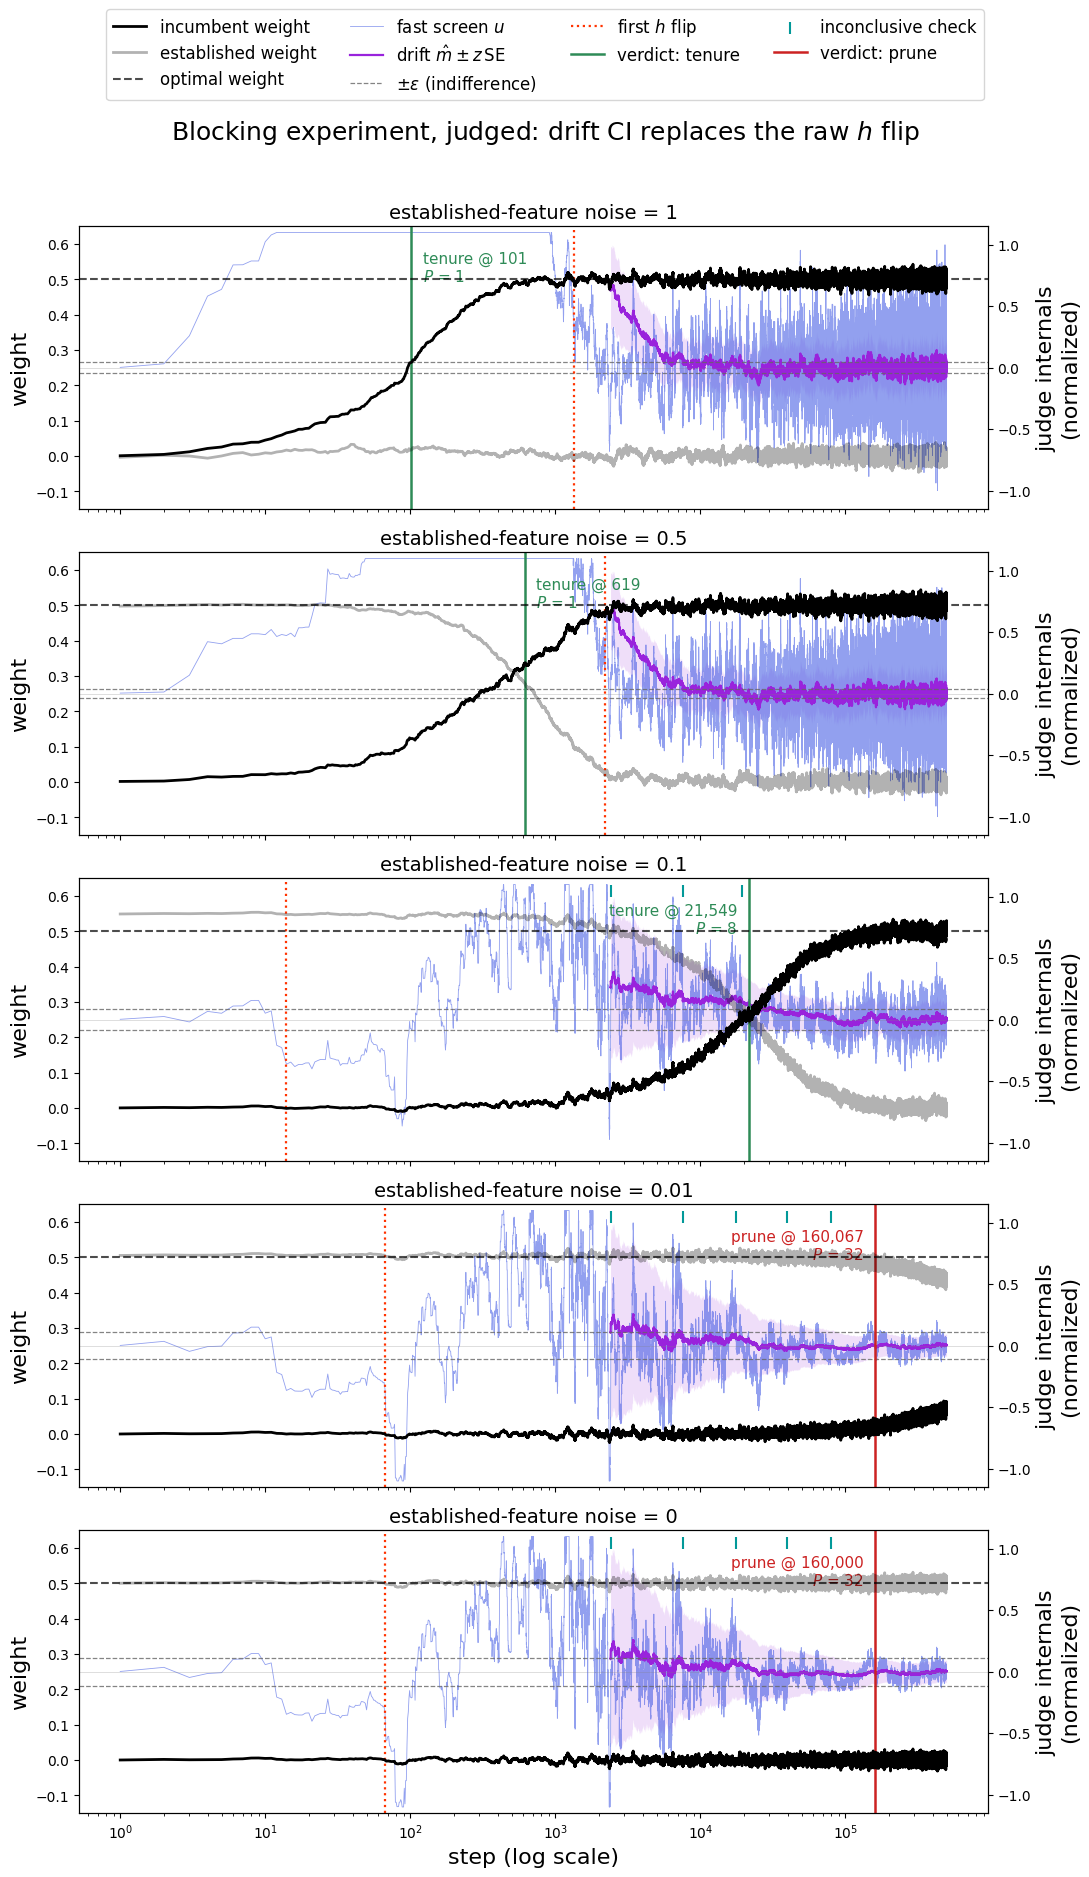

In [12]:
# ---------------------------------------------------------------------------
# Plot: same layout as the earlier blocking figure. Left axis, the two weights
# (true scale). Right axis (normalized): the judge's slow drift estimate m_hat
# with its +/- z*SE band, the fast screen u, and the eps indifference corridor;
# the CONVERGED verdict fires where the band fits inside the corridor. Vertical
# lines mark the first h flip (the old rule) and the judge's verdict.
# ---------------------------------------------------------------------------
JUDGE_M_COLOR, JUDGE_U_COLOR = '#9923DC', '#3953e2'
INC_COLOR, VETO_COLOR = '#029999', '#FF8C00'
TENURE_COLOR, PRUNE_COLOR = '#2E8B57', '#CC2222'

plot_steps = np.arange(1, N_STEPS_BLOCK + 1)
w_opt = optimal_weight(W_TEACHER, INCUMBENT_NOISE)
fig, axes = plt.subplots(len(EST_NOISES), 1,
                         figsize=(11, 3.6 * len(EST_NOISES)), sharex=True)
all_ax2 = []
for ax, c_est in zip(axes, EST_NOISES):
    r = results_judge[c_est]
    h = r['hist']
    t0 = int(JUDGE_KAPPA / (STEP_SIZE * r['judge'].s2_hat()))  # initial window

    # --- right axis: judge internals, normalized past the initial window ---
    ax2 = ax.twinx()
    se = np.nan_to_num(h['se'], posinf=1e3)
    m, u = h['m'].astype(float), h['u'].astype(float)
    m[:t0] = np.nan; se_m = se.astype(float); se_m[:t0] = np.nan  # immature
    norm_m = max(np.nanmax(np.abs(m) + JUDGE_Z * se_m), 1e-12)
    norm_u = max(np.max(np.abs(u[t0:])), 1e-12)
    eps_n = r['judge'].eps() / norm_m
    ax2.fill_between(plot_steps, (m - JUDGE_Z * se_m) / norm_m,
                     (m + JUDGE_Z * se_m) / norm_m,
                     color=JUDGE_M_COLOR, alpha=0.15, lw=0)
    ax2.plot(plot_steps, np.clip(u / norm_u, -1.1, 1.1), color=JUDGE_U_COLOR,
             lw=0.6, alpha=0.55, label='fast screen $u$')
    ax2.plot(plot_steps, m / norm_m, color=JUDGE_M_COLOR,
             lw=1.6, label='drift $\\hat m \\pm z\\,\\mathrm{SE}$')
    ax2.axhline(eps_n, color='0.4', ls='--', lw=0.9, alpha=0.8,
                label='$\\pm\\varepsilon$ (indifference)')
    ax2.axhline(-eps_n, color='0.4', ls='--', lw=0.9, alpha=0.8)
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('judge internals\n(normalized)', fontsize=16)

    # events and verdicts
    for name, marker, col in [('inconclusive', '|', INC_COLOR),
                              ('veto', '^', VETO_COLOR)]:
        ts = [t + 1 for t, e in r['events'] if e == name]
        if ts:
            ax2.scatter(ts, [1.05] * len(ts), marker=marker, s=70, color=col,
                        label=f'{name} check', zorder=11, clip_on=False)
    if r['h_first_flip'] is not None:
        ax2.axvline(r['h_first_flip'] + 1, color=H_IDBD3_COLOR, ls=':',
                    lw=1.6, label='first $h$ flip')
    if r['verdict'] is not None:
        tv, kind, wi, we, P = r['verdict']
        col = TENURE_COLOR if kind == 'tenure' else PRUNE_COLOR
        ax2.axvline(tv + 1, color=col, lw=1.8, label=f'verdict: {kind}')
        frac = np.log(tv + 1) / np.log(N_STEPS_BLOCK)
        ax2.annotate(f'{kind} @ {tv:,}\n$P$ = {P:.0f}', xy=(tv + 1, 0.7),
                     xytext=(-8 if frac > 0.6 else 8, 0), textcoords='offset points',
                     ha='right' if frac > 0.6 else 'left', fontsize=11, color=col)

    # --- left axis: the weights (true scale, black), drawn on top ---
    ax.plot(plot_steps, h['w_inc'], color=W_COLOR, lw=2.0,
            label='incumbent weight', zorder=10)
    ax.plot(plot_steps, h['w_est'], color=W_COLOR, lw=2.0, alpha=0.3,
            label='established weight', zorder=10)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'established-feature noise = {c_est:.3g}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    all_ax2.append(ax2)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Blocking experiment, judged: drift CI replaces the raw $h$ flip',
             fontsize=18)
seen, H, L = set(), [], []
for a in list(axes) + all_ax2:
    for hh, ll in zip(*a.get_legend_handles_labels()):
        if ll not in seen:
            seen.add(ll); H.append(hh); L.append(ll)
fig.legend(H, L, loc='upper center', ncol=4, fontsize=12,
           bbox_to_anchor=(0.5, 1.045))
fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.show()